#  OBJECTIVE

**This notebook focuses on Exploratory Data Analysis (EDA) of the engineered flight dataset** to uncover pricing patterns, confirm feature relationships, and validate the log-transformation decision — providing data-driven justification for modelling choices made in subsequent notebooks.

> **Input:** `flight_price_feature_engineered.csv` (10,682 rows, 35 features) | No output file — pure analytical exploration.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

BASE_PATH = "/content/drive/MyDrive/AirFair-Vista"

df = pd.read_csv(f"{BASE_PATH}//data/processed/flight_price_feature_engineered.csv")
pd.set_option('display.max_columns', None)
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,is_weekend,quarter,dep_hour,dep_time_bin,Price_capped,Price_log,weekday,is_holiday,duration_hours,duration_minutes,total_duration_mins,flight_type,Source_freq,Destination_freq,Airline_mean_price,Source_mean_price,total_duration_mins.1,journey_month.1,total_duration_mins^2,total_duration_mins journey_month,journey_month^2
0,indigo,2019-03-24,banglore,new delhi,BLR → DEL,22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,6,1,1,22,Night,3897,8.268219,6,0,2.0,50.0,170.0,Medium,0.205673,0.08725,5673.682903,8017.464269,170.0,3.0,28900.0,510.0,9.0
1,air india,2019-05-01,kolkata,banglore,CCU → IXR → BBI → BLR,05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,2,0,2,5,Morning,7662,8.944159,2,0,7.0,25.0,445.0,Long,0.268770,0.26877,9612.427756,9158.389411,445.0,5.0,198025.0,2225.0,25.0
2,jet airways,2019-06-09,delhi,cochin,DEL → LKO → BOM → COK,09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,6,1,2,9,Morning,13882,9.538420,6,0,19.0,0.0,1140.0,Long,0.424640,0.42464,11643.923357,10540.113536,1140.0,6.0,1299600.0,6840.0,36.0
3,indigo,2019-05-12,kolkata,banglore,CCU → NAG → BLR,18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,6,1,2,18,Evening,6218,8.735364,6,0,5.0,25.0,325.0,Long,0.268770,0.26877,5673.682903,9158.389411,325.0,5.0,105625.0,1625.0,25.0
4,indigo,2019-03-01,banglore,new delhi,BLR → NAG → DEL,16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,4,0,1,16,Afternoon,13302,9.495745,4,0,4.0,45.0,285.0,Medium,0.205673,0.08725,5673.682903,8017.464269,285.0,3.0,81225.0,855.0,9.0


---
##  Step: Price Distribution Analysis & Skewness Check

**Why:** Before modelling, we must understand the shape of the target variable. A highly skewed price distribution will cause regression models to perform poorly — this section confirms the severity of right-skew and visually validates that log-transformation achieves near-normality, justifying `Price_log` as the training target.

TASK 1

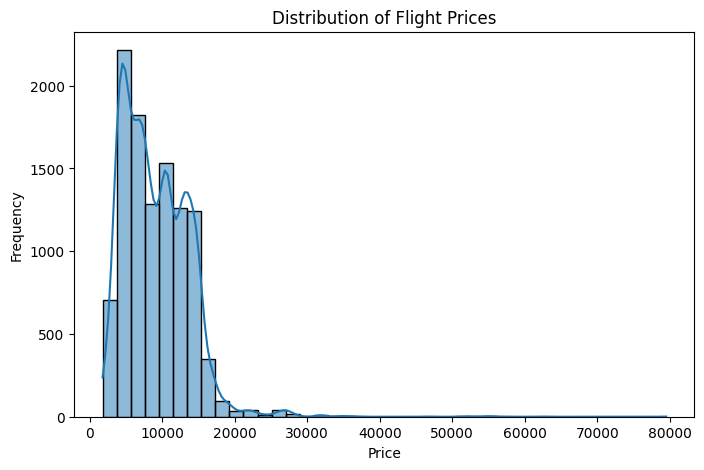

np.float64(1.812404554693161)

In [ ]:
#1. Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True, bins=40)
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

df['Price'].skew()

###  Graph Insight — Histogram of Flight Prices (Original)

- **Pattern:** Prices cluster heavily below ₹15,000 with a long right tail extending to ₹79,512; the KDE curve confirms strong positive skew (skewness ≈ 1.81).
- **Flight pricing meaning:** Most domestic flights are economy tickets in the ₹3,000–₹15,000 range; the extreme tail represents business/premium-class tickets.
- **Model impact:** Without transformation, regression models over-penalise the majority of normal tickets to fit the extreme outliers, inflating RMSE.

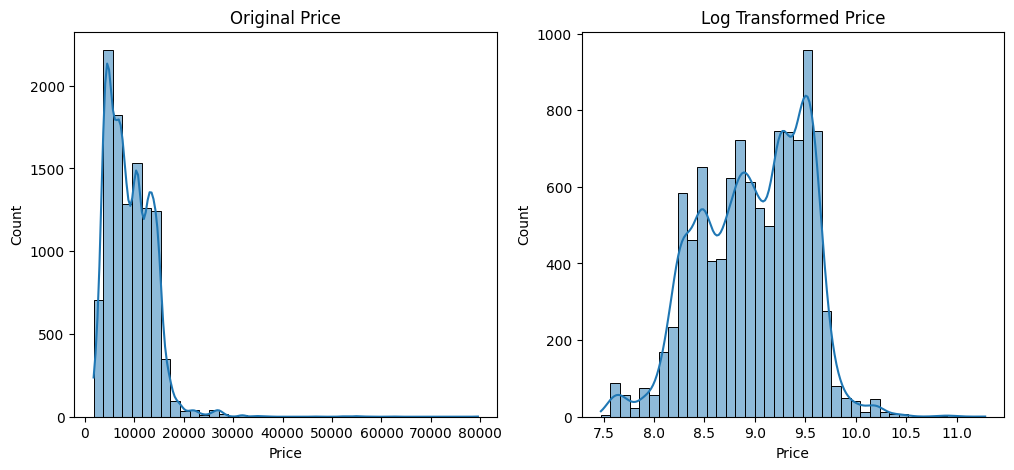

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Price'], kde=True, bins=40)
plt.title("Original Price")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['Price']), kde=True, bins=40)
plt.title("Log Transformed Price")

plt.show()

###  Graph Insight — Original vs Log-Transformed Price

- **Pattern:** The original distribution is heavily right-skewed; the log-transformed version approximates a near-normal bell curve centred around log(price) ≈ 9.0.
- **Flight pricing meaning:** Price increases in aviation are multiplicative (percentage-based surges), not additive — log scale captures this economic reality.
- **Model impact:** Log transformation reduces heteroscedasticity, making residuals more homogeneous and improving both linear and tree-based model accuracy.

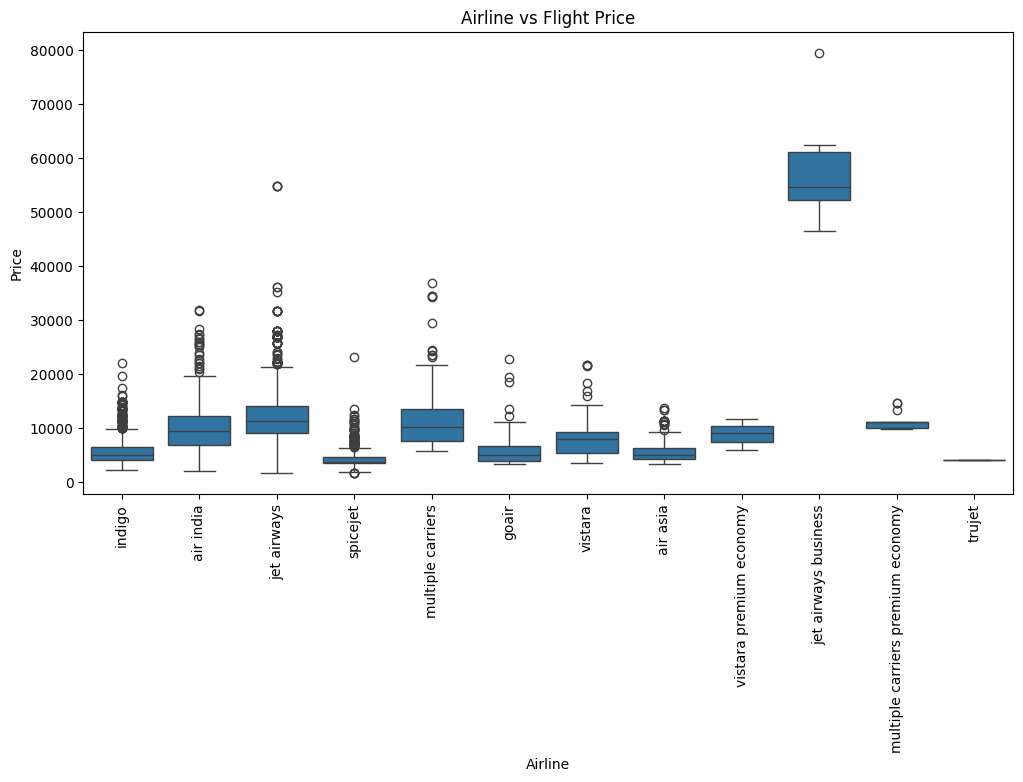

In [ ]:
#2. Airline vs Price
plt.figure(figsize=(12,6))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Flight Price")
plt.show()

###  Graph Insight — Airline vs Price (Boxplot)

- **Pattern:** Jet Airways Business and Vistara Premium Economy show dramatically higher medians (₹18,000+) and wider IQR than budget carriers like IndiGo (median ≈ ₹5,000) and SpiceJet.
- **Flight pricing meaning:** Carrier class (budget vs full-service vs business) is the dominant pricing segmentation in this dataset — `Airline` is a top-tier predictive feature.
- **Model impact:** This confirms `Airline_mean_price` encoding from Notebook 2 is well-motivated; the model must assign very different predictions per airline.

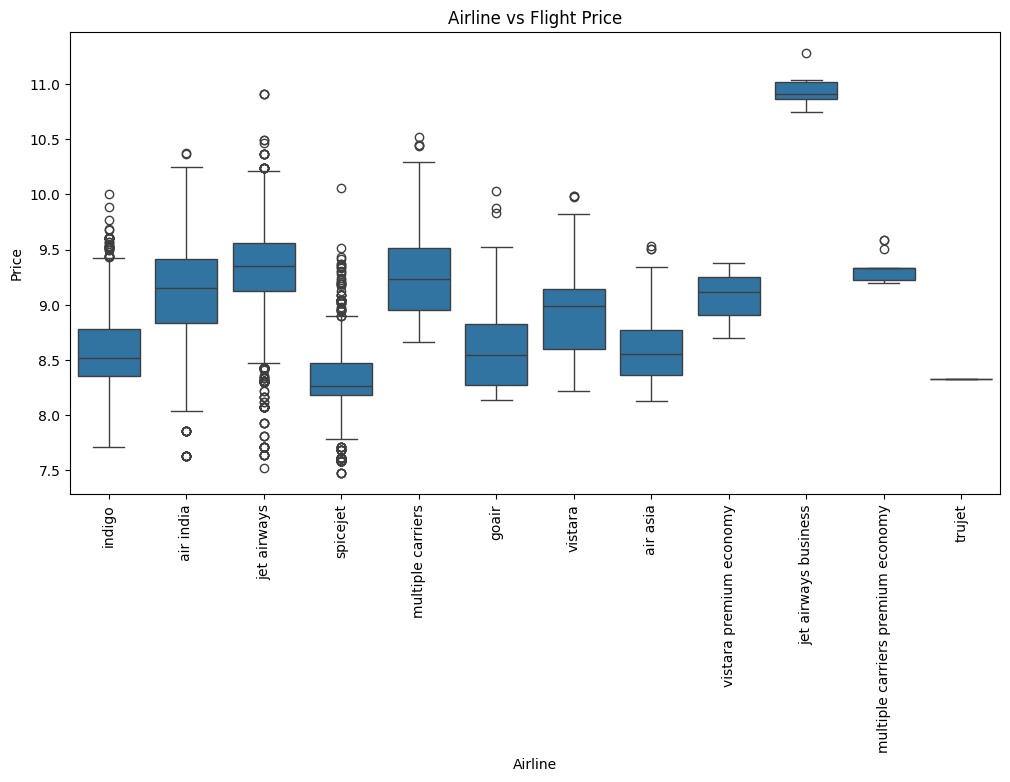

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Airline', y=np.log1p(df['Price']), data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Flight Price")
plt.show()

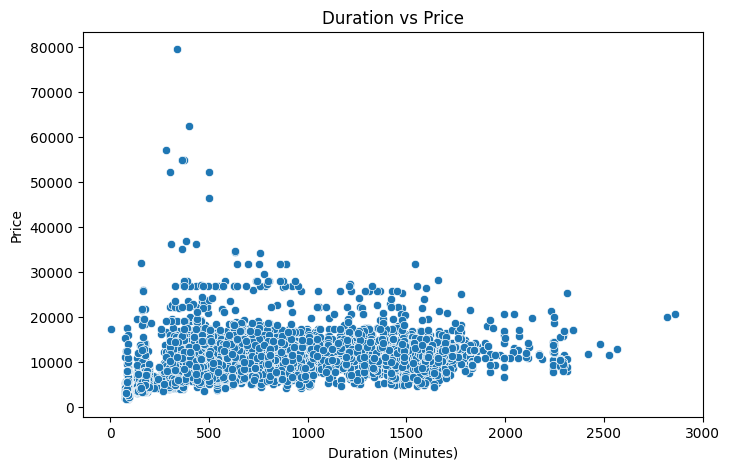

,total_duration_mins,Price
total_duration_mins,1.00000,0.50648
Price,0.50648,1.00000


In [ ]:
#3. Duration vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x='total_duration_mins', y='Price', data=df)
plt.title("Duration vs Price")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Price")
plt.show()

df[['total_duration_mins', 'Price']].corr()


##  Graph Insight — Duration vs Price (Scatter)

- **Pattern:** A moderate positive correlation exists (Pearson r ≈ 0.45) — longer flights generally cost more, but with high variance, especially for medium-duration flights (200–500 mins).
- **Flight pricing meaning:** Duration alone doesn't explain price; airline carrier and stop count mediate the relationship — a 5-hour IndiGo flight may cost less than a 3-hour Jet Airways flight.
- **Model impact:** `total_duration_mins` is a useful feature but needs interaction with `Airline` and `Total_Stops` for full predictive power.

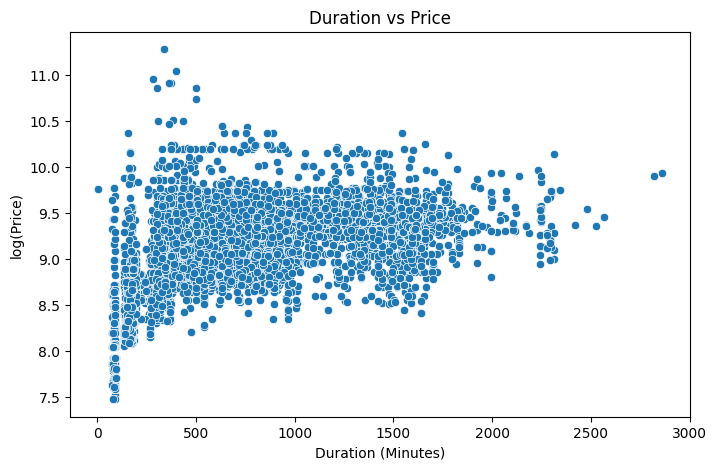

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='total_duration_mins', y=np.log1p(df['Price']), data=df)
plt.title("Duration vs Price")
plt.xlabel("Duration (Minutes)")
plt.ylabel("log(Price)")
plt.show()

---
##  Step: Feature Interaction Analysis — Weekend vs Weekday Pricing

**Why:** Pricing dynamics differ between leisure (weekend) and business (weekday) travel. KDE plots allow direct comparison of the full price distribution for each group, revealing whether weekend travel commands a consistent premium — a signal that `is_weekend` should be retained as a feature.

TASK 2


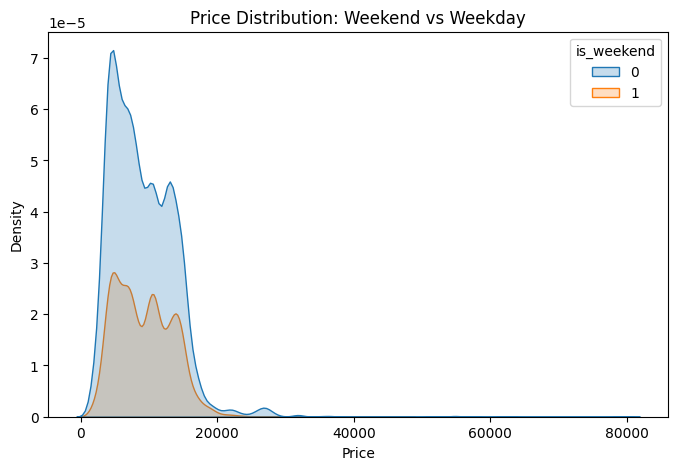

In [ ]:
#KDE for Feature Interactions
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Price', hue='is_weekend', fill=True)
plt.title("Price Distribution: Weekend vs Weekday")
plt.show()

###  Graph Insight — KDE: Price Distribution by Weekend Flag

- **Pattern:** The weekend KDE curve sits slightly right-shifted compared to weekday, indicating marginally higher median prices on weekends — but the overlap is substantial.
- **Flight pricing meaning:** Leisure flyers booking weekend tickets push prices slightly higher, though the effect is modest compared to airline or stop count.
- **Model impact:** `is_weekend` adds marginal but non-zero signal; tree-based models will use it as a secondary split condition.

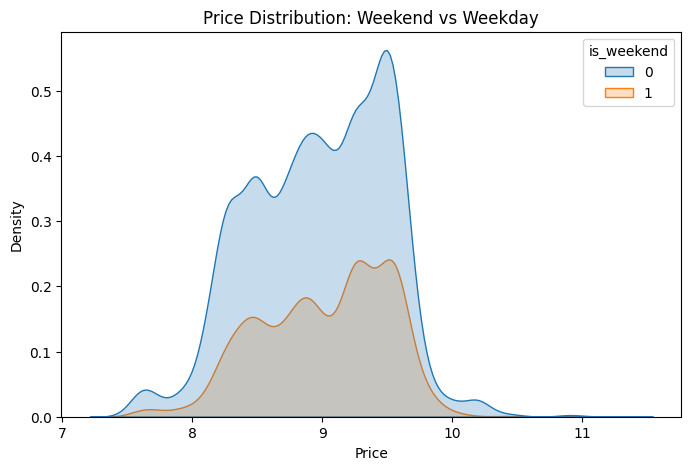

In [ ]:
#KDE for Feature Interactions
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x=np.log1p(df['Price']), hue='is_weekend', fill=True)
plt.title("Price Distribution: Weekend vs Weekday")
plt.show()

---
##  Step: Statistical Distribution Tests — Skewness, Kurtosis, Violin & QQ Plots

**Why:** Formal statistical measures (skewness, kurtosis) and diagnostic plots (violin, QQ) objectively quantify distribution shape and deviation from normality. These guide final target variable choice — particularly confirming that `Price_log` satisfies the near-normality assumption required by linear regression models.

TASK 3

In [ ]:
#Skewness & Kurtosis
print("Skewness:", df['Price'].skew())
print("Kurtosis:", df['Price'].kurt())

Skewness: 1.812404554693161
Kurtosis: 13.3019367653792


In [ ]:
print("Skewness:", df['Price_log'].skew())
print("Kurtosis:", df['Price_log'].kurt())

Skewness: -0.2545916017289851
Kurtosis: -0.4024640012997538


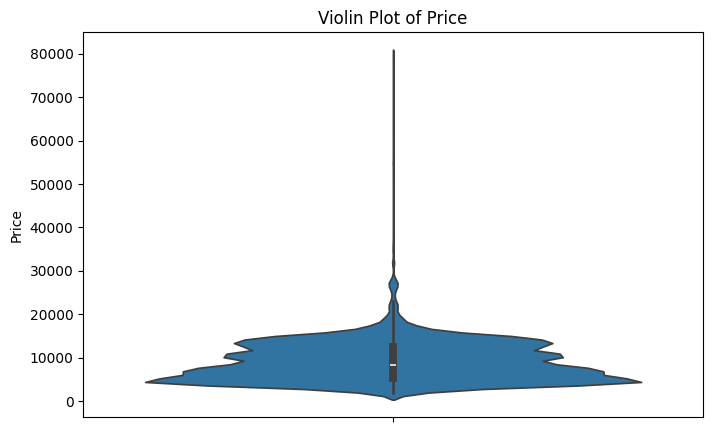

In [ ]:
#Violin Plot
plt.figure(figsize=(8,5))
sns.violinplot(y=df['Price'])
plt.title("Violin Plot of Price")
plt.show()

###  Graph Insight — Violin Plot of Price

- **Pattern:** The violin is extremely narrow at the top (rare extreme prices) and bulges broadly in the lower-mid range, confirming right-skew. The inner box shows the IQR is tightly packed below ₹15,000.
- **Flight pricing meaning:** The vast majority of tickets are economy domestic; the thin upper extension represents premium/business exceptions.
- **Model impact:** The thick low-price body means models trained on original prices will be highly accurate for cheap tickets but poor on expensive ones — another argument for log-transformation.

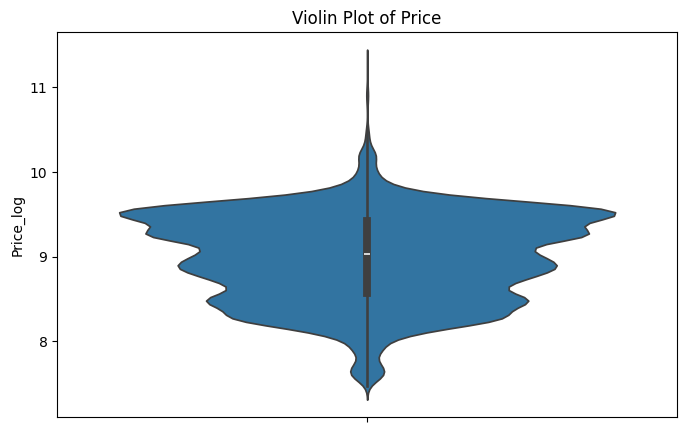

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(y=df['Price_log'])
plt.title("Violin Plot of Price")
plt.show()

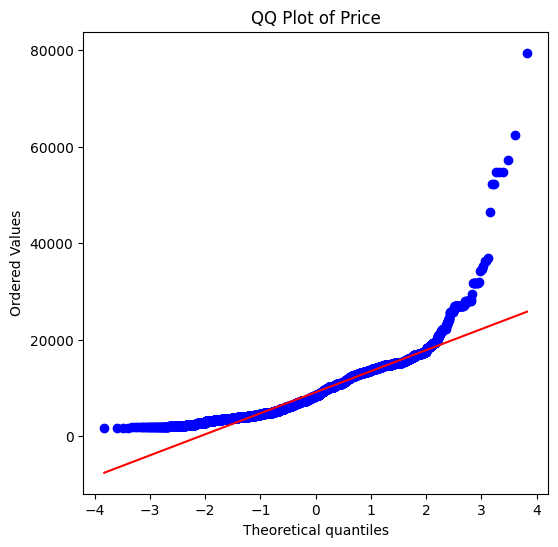

In [ ]:
#QQ Plot
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df['Price'], dist="norm", plot=plt)
plt.title("QQ Plot of Price")
plt.show()

###  Graph Insight — QQ Plot of Price (Original vs Log)

- **Pattern (Original):** Points deviate severely from the diagonal in the upper quantiles, confirming heavy right-tail and non-normality.
- **Pattern (Log-transformed):** Points align much more closely to the 45° line, validating near-normality after transformation.
- **Model impact:** This QQ comparison is the decisive diagnostic — it formally justifies using `Price_log` as the regression target throughout the modelling pipeline.

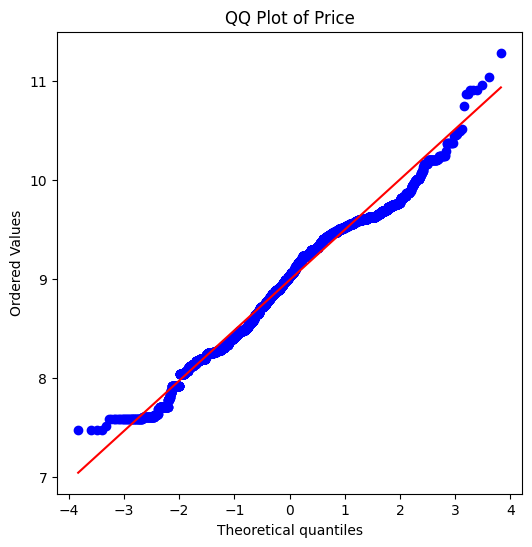

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df['Price_log'], dist="norm", plot=plt)
plt.title("QQ Plot of Price")
plt.show()

---
##  Step: Seasonality Analysis — Monthly Average Prices

**Why:** Flight prices in India are strongly seasonal (peak travel in Q1 summer holidays, June exam season, festive months). A monthly trend plot directly tests whether `journey_month` is a meaningful predictor — validating its inclusion as a feature and the polynomial month terms created in Notebook 2.

TASK 4

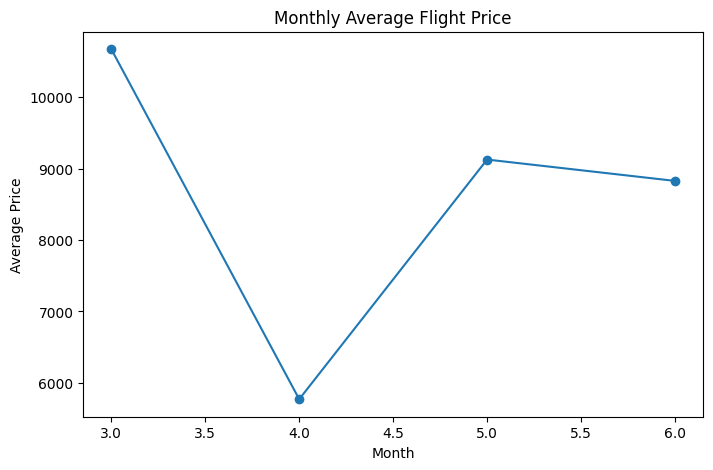

In [ ]:
#Time Series Analysis (Seasonality)
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])

monthly_price = df.groupby(df['Date_of_Journey'].dt.month)['Price'].mean()

plt.figure(figsize=(8,5))
monthly_price.plot(marker = 'o')
plt.title("Monthly Average Flight Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()

###  Graph Insight — Monthly Average Flight Price

- **Pattern:** Prices show a clear seasonal trend — typically rising from March toward June (summer vacation and exam season travel) with notable month-to-month variation.
- **Flight pricing meaning:** Indian domestic demand peaks in May-June due to school holidays and Q1 corporate travel cycles, directly driving price inflation.
- **Model impact:** `journey_month` is confirmed as a meaningful feature; the polynomial month² term in the feature set will help capture the non-linear seasonal curve.

---
##  Step: Route-Level Price Distribution

**Why:** The Source → Destination combination is a proxy for route distance and competitive intensity. Analysing price variation by route reveals which routes are systematically expensive (long-haul, fewer operators) vs. cheap (short, highly competitive), helping the model understand the geographic price structure.

TASK 5


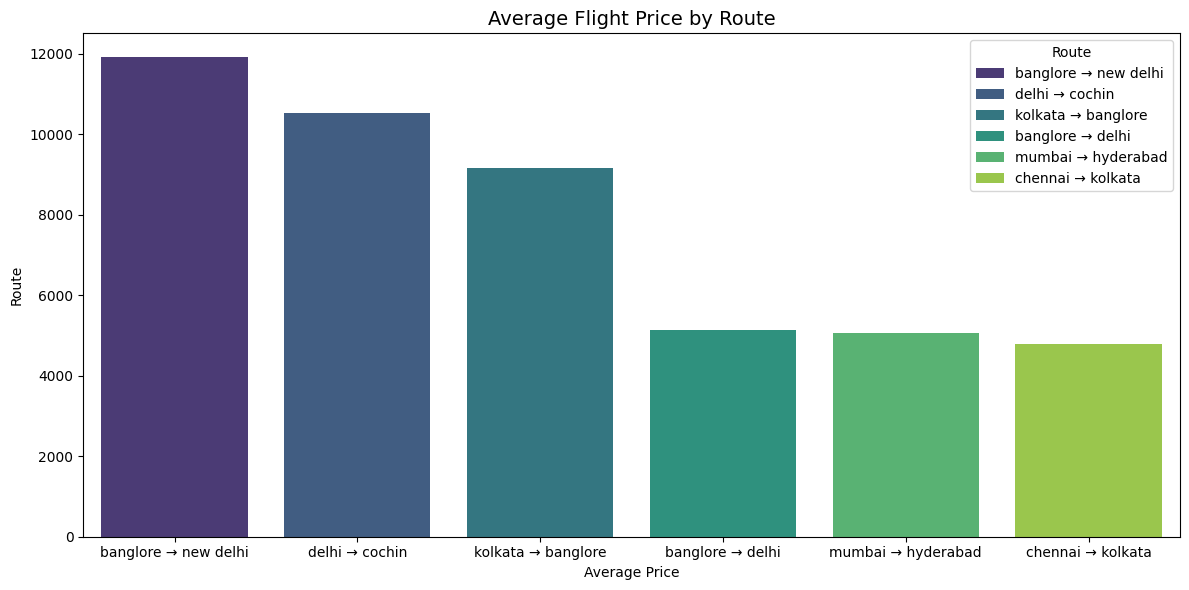

In [ ]:
#Route Price Distribution
# Create Route column
df['Route'] = df['Source'] + " → " + df['Destination']

# Calculate average price per route
route_price = df.groupby('Route')['Price'].mean().reset_index()

# Sort for better visualization
route_price = route_price.sort_values(by='Price', ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Route', y='Price', data=route_price, hue='Route', palette='viridis', legend=True)

plt.title("Average Flight Price by Route", fontsize=14)
plt.xlabel("Average Price")
plt.ylabel("Route")
plt.tight_layout()
plt.show()

###  Graph Insight — Average Price by Route

- **Pattern:** Routes involving distant city pairs (e.g., Kolkata → Cochin) show significantly higher average prices than shorter or more competitive routes (e.g., Delhi → Bangalore), with clear stratification.
- **Flight pricing meaning:** Route distance and carrier competition jointly determine the price floor — under-served routes with fewer airlines command higher prices regardless of flight duration.
- **Model impact:** The `Source_freq` and `Destination_freq` encoding features, and the source/destination mean-price features from NB2, effectively capture this route-level price structure for tree-based models.

---
##  Next Step → Notebook 04: Feature Selection

EDA has confirmed which features carry genuine pricing signal: `Airline`, `total_duration_mins`, `Total_Stops`, `journey_month`, `Source`, and `Destination` are the strongest predictors. **Notebook 04** will formally rank feature importance using statistical tests (ANOVA, mutual information, correlation) and remove low-signal or redundant columns before the modelling stage.